<a href="https://colab.research.google.com/github/Bhuvana170806/AI-Health-Chatbot/blob/main/network%20fault.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

# Load dataset (no headers)
df = pd.read_csv("KDDTrain+.txt", header=None)

# Show first rows
df.head()

KeyboardInterrupt: 

In [4]:
import pandas as pd

# Load dataset (no headers)
df = pd.read_csv("KDDTrain+.txt", header=None)

# Show first rows
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label','difficulty'
]

df.columns = columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
df['fault'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

df[['label','fault']].head()

,label,fault
0,normal,0
1,normal,0
2,neptune,1
3,normal,0
4,normal,0


In [7]:
df['latency'] = df['duration']
df['packet_loss'] = df['wrong_fragment']
df['jitter'] = df['duration'].diff().fillna(0).abs()

df[['latency','packet_loss','jitter']].head()

,latency,packet_loss,jitter
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0


In [8]:
df[['latency','packet_loss','jitter']].describe()

,latency,packet_loss,jitter
count,125973.00000,125973.000000,125973.000000
mean,287.14465,0.022687,565.299437
std,2604.51531,0.253530,3631.470897
min,0.00000,0.000000,0.000000
25%,0.00000,0.000000,0.000000
50%,0.00000,0.000000,0.000000
75%,0.00000,0.000000,0.000000
max,42908.00000,3.000000,42908.000000


In [9]:
df[['latency','packet_loss','jitter']].tail()

,latency,packet_loss,jitter
125968,0,0,0.0
125969,8,0,8.0
125970,0,0,8.0
125971,0,0,0.0
125972,0,0,0.0


In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Select features
features = df[['latency','packet_loss','jitter']].values

# Normalize
scaler = MinMaxScaler()
features = scaler.fit_transform(features)

# Create sequences
X, y = [], []
seq_length = 10

for i in range(len(features) - seq_length):
    X.append(features[i:i+seq_length])
    y.append(df['fault'].values[i+seq_length])

X = np.array(X)
y = np.array(y)

# Build LSTM
model = Sequential()
model.add(LSTM(50, input_shape=(seq_length, 3)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(X, y, epochs=5)

# Predict last sequence
prediction = model.predict(X[-1].reshape(1, seq_length, 3))

print("Prediction:", prediction)

if prediction[0][0] > 0.5:
    print(" Fault Detected Soon")
else:
    print(" Network Normal")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3937/3937 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.5342 - loss: 0.6909
Epoch 2/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 3/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 4/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 5/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.5346 - loss: 0.6908
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Prediction: [[0.46786967]]
 Network Normal


In [11]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# =========================
# STEP 2: LOAD DATASET
# =========================
df = pd.read_csv("KDDTrain+.txt", header=None)

columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label','difficulty'
]

df.columns = columns

# =========================
# STEP 3: CREATE FAULT LABEL
# =========================
df['fault'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# =========================
# STEP 4: SELECT STRONG FEATURES
# =========================
features = df[['duration','src_bytes','dst_bytes','wrong_fragment','count','srv_count']].values

# =========================
# STEP 5: NORMALIZATION
# =========================
scaler = MinMaxScaler()
features = scaler.fit_transform(features)

# =========================
# STEP 6: CREATE SEQUENCES (TEMPORAL DATA)
# =========================
X, y = [], []
seq_length = 10

for i in range(len(features) - seq_length):
    X.append(features[i:i+seq_length])
    y.append(df['fault'].values[i+seq_length])

X = np.array(X)
y = np.array(y)

# =========================
# STEP 7: BUILD LSTM MODEL
# =========================
model = Sequential([
    Input(shape=(seq_length, 6)),
    LSTM(50),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =========================
# STEP 8: TRAIN MODEL
# =========================
history = model.fit(X, y, epochs=5)

# =========================
# STEP 9: EVALUATE MODEL
# =========================
loss, acc = model.evaluate(X, y)
print("\nAccuracy:", acc)

# =========================
# STEP 10: PREDICTION
# =========================
sample = X[-1].reshape(1, seq_length, 6)
prediction = model.predict(sample)

print("\nPrediction:", prediction)

if prediction[0][0] > 0.5:
    print(" Fault Detected (Network Issue Likely)")
else:
    print("Network Normal")

Epoch 1/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.5344 - loss: 0.6910
Epoch 2/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.5346 - loss: 0.6909
Epoch 3/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 4/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 5/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.5346 - loss: 0.6908
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5346 - loss: 0.6908

Accuracy: 0.5345934629440308
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

Prediction: [[0.47165507]]
Network Normal


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df[['duration','src_bytes','dst_bytes','wrong_fragment','count','srv_count']]
y = df['fault']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9817027187934114


In [13]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("KDDTrain+.txt", header=None)

columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label','difficulty'
]

df.columns = columns

# =========================
# FAULT LABEL
# =========================
df['fault'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# =========================
# SELECT STRONG FEATURES
# =========================
features = df[['duration','src_bytes','dst_bytes','count','srv_count']]

# =========================
# NORMALIZE
# =========================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# =========================
# CREATE TEMPORAL SEQUENCES
# =========================
X, y = [], []
seq_length = 20   # bigger window improves learning

for i in range(len(features_scaled) - seq_length):
    X.append(features_scaled[i:i+seq_length])
    y.append(df['fault'].values[i+seq_length])

X = np.array(X)
y = np.array(y)

# =========================
# BUILD LSTM MODEL
# =========================
model = Sequential([
    Input(shape=(seq_length, X.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =========================
# TRAIN (IMPORTANT CHANGE)
# =========================
model.fit(X, y, epochs=10, batch_size=64)

# =========================
# EVALUATE
# =========================
loss, acc = model.evaluate(X, y)
print("\nAccuracy:", acc)

# =========================
# PREDICT
# =========================
sample = X[-1].reshape(1, seq_length, X.shape[2])
prediction = model.predict(sample)

print("\nPrediction:", prediction)

if prediction[0][0] > 0.5:
    print(" Fault Likely Soon")
else:
    print(" Network Normal")

Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - accuracy: 0.5345 - loss: 0.6909
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 86s 27ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.5346 - loss: 0.6908
Epoch 9/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.5346 - loss: 0.6907
Epoch 10/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.5346 - loss: 0.6908
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - accuracy: 0.5346 - loss: 0.6907

Accuracy: 0.53460419

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# CREATE TIME SERIES DATA (REALISTIC NETWORK BEHAVIOR)
data = {
    "latency":[10,12,15,18,20,25,30,40,55,70,90,120],
    "packet_loss":[0,0,1,1,2,3,5,8,12,18,25,35],
    "jitter":[1,2,2,3,4,5,7,10,15,20,30,40]
}

df = pd.DataFrame(data)

# FAULT LABEL
df['fault'] = df.apply(lambda x: 1 if x['latency'] > 60 or x['packet_loss'] > 15 else 0, axis=1)

# NORMALIZE
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['latency','packet_loss','jitter']])

# CREATE SEQUENCES
X, y = [], []
seq_length = 3

for i in range(len(scaled)-seq_length):
    X.append(scaled[i:i+seq_length])
    y.append(df['fault'].values[i+seq_length])

X = np.array(X)
y = np.array(y)

# MODEL
model = Sequential()
model.add(LSTM(50, input_shape=(seq_length,3)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TRAIN
model.fit(X, y, epochs=50)

# TEST
pred = model.predict(X)
print(pred)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.6667 - loss: 0.7112
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6667 - loss: 0.7086
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6667 - loss: 0.7061
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.6667 - loss: 0.7036
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6667 - loss: 0.7012
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6667 - loss: 0.6987
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6667 - loss: 0.6963
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6667 - loss: 0.6939
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6667 - loss: 0.6916
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6667 - loss: 0.6892
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6667 - loss: 0.6869
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6667 - loss: 

In [3]:
for p in pred:
    if p < 0.4:
        print("Normal")
    elif p < 0.5:
        print("Warning")
    else:
        print("Fault Likely")

Normal
Normal
Warning
Warning
Warning
Warning
Warning
Fault Likely
Fault Likely


/tmp/ipykernel_2719/2927527323.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  values = [float(p) for p in pred]


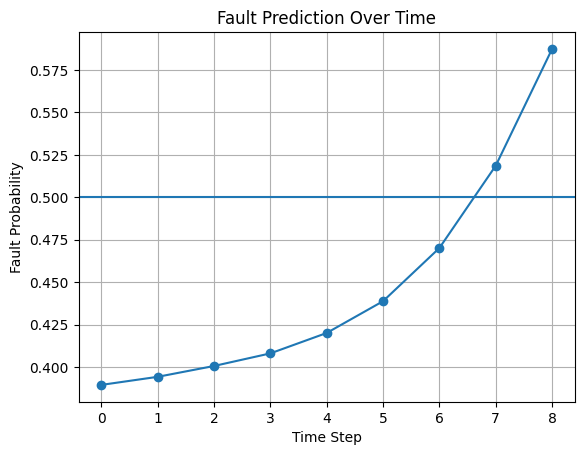

In [4]:
import matplotlib.pyplot as plt

values = [float(p) for p in pred]

plt.plot(values, marker='o')
plt.title("Fault Prediction Over Time")
plt.xlabel("Time Step")
plt.ylabel("Fault Probability")

plt.axhline(0.5)
plt.grid()

plt.show()

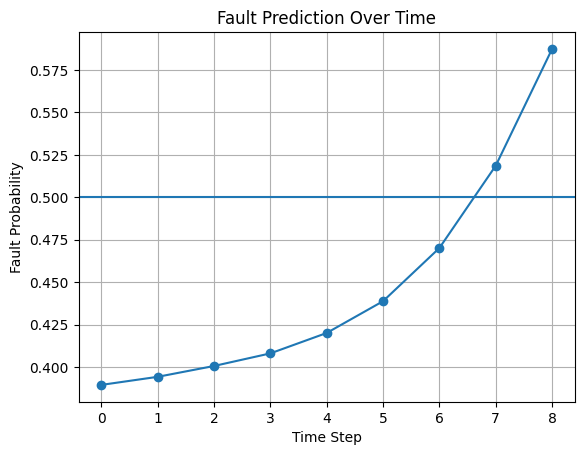

In [5]:
import matplotlib.pyplot as plt

values = [p[0] for p in pred]

plt.plot(values, marker='o')
plt.title("Fault Prediction Over Time")
plt.xlabel("Time Step")
plt.ylabel("Fault Probability")

plt.axhline(0.5)
plt.grid()

plt.show()